In [1]:
import pandas as pd

df = pd.read_csv('../data/train.csv')
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [4]:
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)


In [5]:

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')





C:\Users\acer\AppData\Local\Temp\ipykernel_7576\882293449.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [6]:
import numpy as np

np.random.seed(42)
df['lat'] = np.random.uniform(40.0, 42.0, len(df))
df['lon'] = np.random.uniform(-94.0, -92.0, len(df))


In [7]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Missing')


C:\Users\acer\AppData\Local\Temp\ipykernel_7576\2127586539.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [8]:
import numpy as np

np.random.seed(42)

df['lat'] = np.random.uniform(40.0, 42.0, len(df))
df['lon'] = np.random.uniform(-94.0, -92.0, len(df))



In [9]:
city_lat, city_lon = 41.0, -93.0

df['distance_to_center'] = np.sqrt(
    (df['lat'] - city_lat)**2 +
    (df['lon'] - city_lon)**2
)

In [10]:
df[['lat', 'lon', 'distance_to_center']].head()|

SyntaxError: invalid syntax (393194171.py, line 1)

In [ ]:
df[['lat', 'lon', 'distance_to_center']].head()

,lat,lon,distance_to_center
0,40.749080,-93.212271,0.328664
1,41.901429,-92.697534,0.950820
2,41.463988,-93.786814,0.913434
3,41.197317,-92.684309,0.372283
4,40.312037,-92.001173,1.212827


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 26006.400442967883


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Top 10 features
imp_df.head(10)

,Feature,Importance
4,OverallQual,0.425494
26,GarageCars,0.041287
16,GrLivArea,0.040666
194,CentralAir_Y,0.027057
218,GarageType_Detchd,0.024118
23,TotRmsAbvGrd,0.021221
13,1stFlrSF,0.018033
14,2ndFlrSF,0.016794
174,BsmtFinType1_GLQ,0.016442
201,KitchenQual_Gd,0.015414


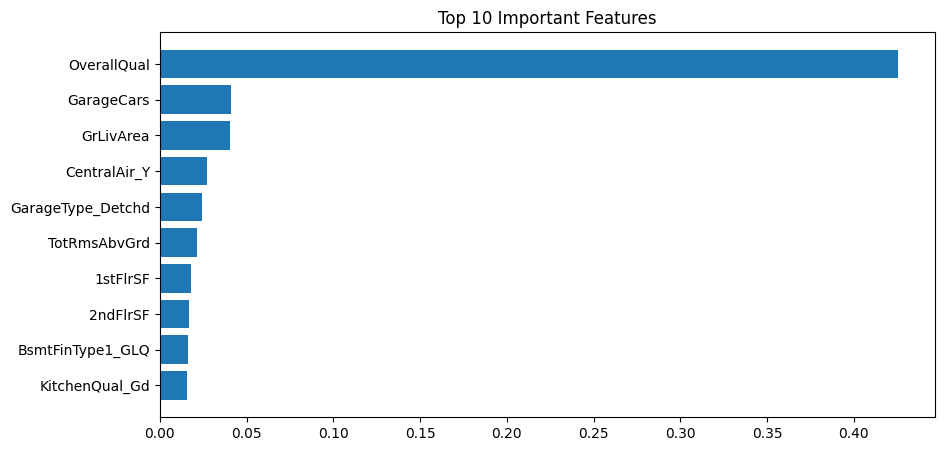

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(imp_df['Feature'][:10], imp_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

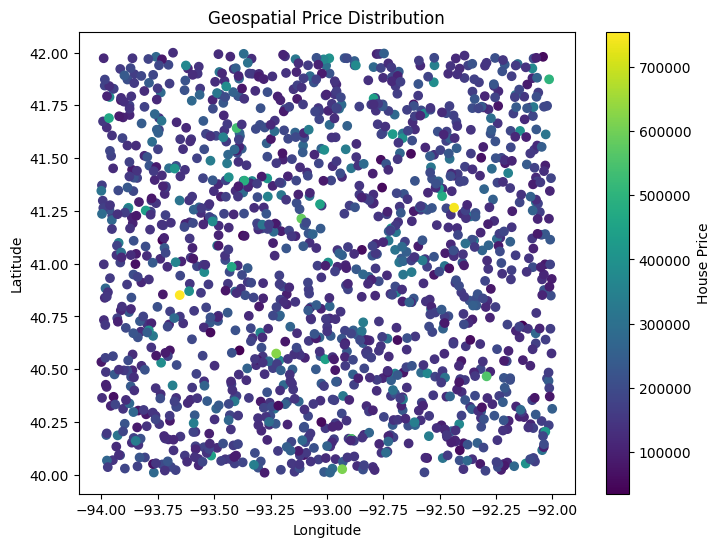

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['lon'], df['lat'], c=df['SalePrice'], cmap='viridis')
plt.colorbar(label='House Price')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geospatial Price Distribution")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import pickle
import os

# Load data
df = pd.read_csv("data/train.csv")

# Simple features (for now)
features = ['OverallQual', 'GrLivArea', 'GarageCars']
target = 'SalePrice'

X = df[features]
y = df[target]

# Train model
model = XGBRegressor()
model.fit(X, y)

# Save model properly
os.makedirs("model", exist_ok=True)

with open("model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'data/train.csv'

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import pickle
import os

# Load data
df = pd.read_csv("../data/train.csv")

# Simple features (for now)
features = ['OverallQual', 'GrLivArea', 'GarageCars']
target = 'SalePrice'

X = df[features]
y = df[target]

# Train model
model = XGBRegressor()
model.fit(X, y)

# Save model properly
os.makedirs("model", exist_ok=True)

with open("model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import pickle
import os

# Load dataset (IMPORTANT PATH)
df = pd.read_csv("../data/train.csv")

# Select features
features = ['OverallQual', 'GrLivArea', 'GarageCars']
target = 'SalePrice'

X = df[features]
y = df[target]

# Train model
model = XGBRegressor()
model.fit(X, y)

# Save model (IMPORTANT FIX)
os.makedirs("../model", exist_ok=True)

with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved correctly!")

✅ Model saved correctly!


In [ ]:
from xgboost import XGBRegressor
import pickle

model = XGBRegressor()
model.fit(X, y)

with open("model/model.pkl", "wb") as f:
    pickle.dump(model, f)
    
